In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from aeon.classification import BaseClassifier
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.datasets.tsc_datasets import univariate

from tscglue import utils
import polars as pl
from pathlib import Path
from aeon.visualisation import plot_critical_difference
from sklearn.linear_model import RidgeClassifierCV
from aeon.transformations.collection import Normalizer
from aeon.datasets.tsc_datasets import univariate
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from aeon.datasets import load_arrow_head
from tscglue.models import NoScaler, SparseScaler
from tabicl import TabICLClassifier, TabICLRegressor
from aeon.transformations.collection import Tabularizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from aeon.utils.validation import check_n_jobs
from itertools import product

In [7]:
class LocalFileCache:
    def __init__(self, base_dir: str):
        self.base_dir = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)

    def exists(self, filename: str) -> bool:
        return (self.base_dir / filename).exists()

    def add(self, df: pl.DataFrame, filename: str):
        df.write_parquet(self.base_dir / filename)

In [8]:
def get_pipeline(TS_scale="no", feature_scale="no", model="RidgeCV"):
    match TS_scale:
        case "no": TS = None
        case "z-norm": TS = Normalizer()
        case _: TS = None
    match feature_scale:
        case "no": feature = NoScaler()
        case "standard": feature = StandardScaler()
        case "quantile": feature = QuantileTransformer()
        case "robust": feature = RobustScaler()
        case "sparse": feature = SparseScaler()
        case _: feature = NoScaler()
    match model:
        case "RidgeCV": m = RidgeClassifierCV()
        case "NN": m = MLPClassifier()
        case "RF": m = RandomForestClassifier()
        case "TabICL": m = TabICLClassifier()
        case _: m = RidgeClassifierCV()
    t = Tabularizer()
    steps = []
    for step in [TS, t, feature, m]:
        if step is not None:
            steps.append(step)

    pipe = make_pipeline(*steps)
    return pipe

In [9]:
TS_options = ["no", "z-norm"]
feature_options = ["no", "standard", "quantile", "robust"]
model_options = ["RidgeCV", "NN", "RF", "TabICL"]

combos = list(product(
    TS_options,
    feature_options,
    model_options,
    univariate,
))


In [10]:
from tqdm import tqdm

cache = LocalFileCache("Tabular")
n = len(combos)
for i, (TS_scale, feature_scale, model_name, dataset) in tqdm(list(enumerate(combos, 1)), total=len(combos)):
    pipe = get_pipeline(
        TS_scale=TS_scale,
        feature_scale=feature_scale,
        model=model_name
    )
    name = f"{model_name}-{feature_scale}-{TS_scale}"
    try:
        stats = {
            "dataset": dataset,
            "model": name,
        }
        hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
        file_name = f"{hash_val}.parquet"
        if cache.exists(file_name):
            # print(f"[{i}/{n}] Skipping: Dataset={dataset}")
            continue
        # else:
        #     print(f"[{i}/{n}] Processing: Dataset={dataset}")
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        acc = accuracy_score(y_test, preds)
        stats["test_accuracy"] = acc
        df_stat = pl.DataFrame([stats])
        cache.add(df_stat, file_name)
    except Exception as e:
        print(f"Error processing Dataset={dataset}: {e}")

100%|██████████| 4096/4096 [00:07<00:00, 553.12it/s]


/tmp/ipykernel_2347216/1910990720.py:2: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix = df.pivot(
/tmp/ipykernel_2347216/1910990720.py:9: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix_scaler = df_scaler.pivot(
/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators TabICL-no-no and TabICL-robust-no have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(ordered_scores, ordered_labels, lower_better)
/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/aeon/visualisation/results/_critical_difference.py:217: UserWarning: Estimators TabICL-no-no and TabICL-standard-no have the same performanceon all datasets. This may cause problems when forming cliques.
  p_values = wilcoxon_test(

(<Figure size 600x520 with 1 Axes>, <Axes: >)

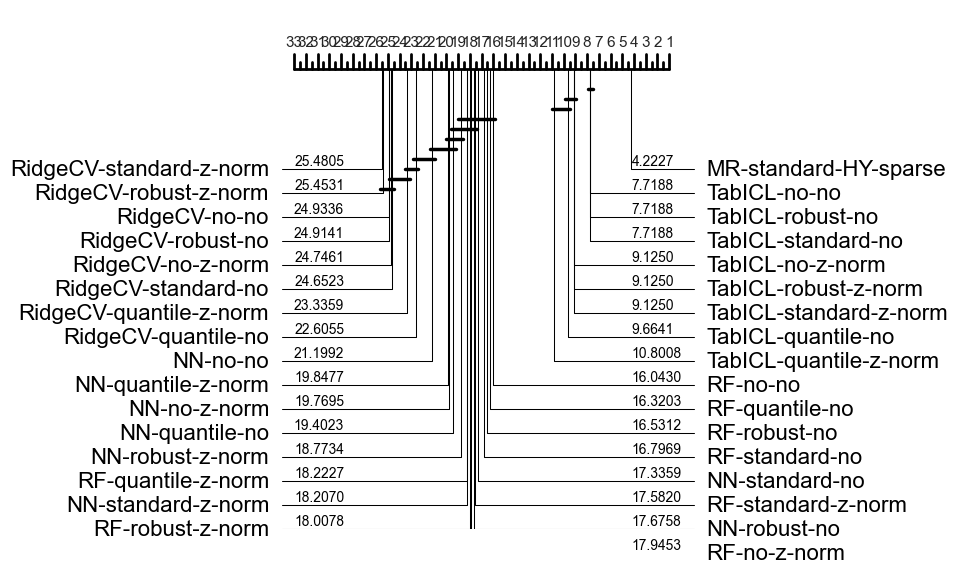

In [11]:
df = pl.read_parquet('Tabular/*.parquet')
df_matrix = df.pivot(
    index="dataset",
    columns="model",
    values="test_accuracy"
)

df_scaler = pl.read_parquet('scaler-combinations/*.parquet')
df_matrix_scaler = df_scaler.pivot(
    index="dataset",
    columns="model",
    values="test_accuracy"
)
model_name = "MR-standard-HY-sparse"

df_filtered = df_matrix_scaler.select([
    "dataset",
    model_name
])

df_joined = df_matrix.join(df_filtered, on="dataset", how="inner")
dfp = df_matrix.to_pandas().set_index("dataset")
scalers_used = df_joined.columns[1:]
accs = df_joined.select(scalers_used).to_numpy().tolist()
plot_critical_difference(accs, scalers_used)